# Local Models vs. Fireworks AI: Side-by-Side Comparison

This notebook compares the quality and latency of a RAG application running on:
- **Local models** via Ollama (llama3.2 + nomic-embed-text)
- **Managed endpoint** via Fireworks AI (gpt-oss-20b + qwen3-embedding-8b)

## Prerequisites
- Ollama installed and running locally (`ollama pull llama3.2 && ollama pull nomic-embed-text`)
- Fireworks API key set in `.env` as `FIREWORKS_API_KEY`
- PDF documents in the `data/` directory for the RAG pipeline

In [3]:
import os
import sys
import time
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

# Load environment variables from .env
load_dotenv()

# Add the app directory to path for imports
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))

from app.rag import _get_rag_graph

print("✓ Imports successful")
print(f"Timestamp: {datetime.now().isoformat()}")

✓ Imports successful
Timestamp: 2026-07-06T20:23:29.002374


## Step 1: Define Test Questions

These queries will be run against both providers to ensure consistency.

In [4]:
# Define a fixed set of test questions
test_questions = [
    "What is the main topic of the document?",
    "What are the key findings or conclusions?",
    "Who are the authors or contributors?",
    "What methods were used in the research?",
    "What are the limitations mentioned?",
]

print(f"Test questions ({len(test_questions)}):")
for i, q in enumerate(test_questions, 1):
    print(f"  {i}. {q}")

Test questions (5):
  1. What is the main topic of the document?
  2. What are the key findings or conclusions?
  3. Who are the authors or contributors?
  4. What methods were used in the research?
  5. What are the limitations mentioned?


## Step 2: Helper Function to Run RAG

This function invokes the RAG pipeline and measures latency.

In [7]:
def run_rag_query(question: str) -> tuple[str, float]:
    """Run a single RAG query and return response text with elapsed time."""
    start_time = time.time()
    try:
        rag_graph = _get_rag_graph()
        result = rag_graph.invoke({"question": question})
        response_text = result.get("response", "(empty response)")
    except Exception as e:
        response_text = f"Error: {str(e)}"
    elapsed = time.time() - start_time
    return response_text, elapsed

print("✓ Helper function defined")

✓ Helper function defined


## Step 3: Run on Fireworks AI

This cell tests the default Fireworks AI endpoint (gpt-oss-20b + qwen3-embedding-8b).

In [8]:
# Configure for Fireworks AI
os.environ["LLM_PROVIDER"] = "fireworks"

# Clear the cached RAG graph to force a rebuild with the new provider
_get_rag_graph.cache_clear()

print("Running RAG on Fireworks AI...")
print(f"Provider: {os.environ.get('LLM_PROVIDER')}")
print(f"Chat Model: {os.environ.get('FIREWORKS_CHAT_MODEL', 'accounts/fireworks/models/gpt-oss-20b')}")
print(f"Embedding Model: {os.environ.get('FIREWORKS_EMBEDDING_MODEL', 'accounts/fireworks/models/qwen3-embedding-8b')}")
print()

fireworks_results = []
for i, question in enumerate(test_questions, 1):
    print(f"[Fireworks] Query {i}/{len(test_questions)}: {question[:50]}...")
    response, latency = run_rag_query(question)
    fireworks_results.append({
        "question": question,
        "response": response,
        "latency_s": latency
    })
    print(f"  ✓ Latency: {latency:.2f}s")

print("\n✓ Fireworks AI run complete")

Running RAG on Fireworks AI...
Provider: fireworks
Chat Model: accounts/fireworks/models/gpt-oss-20b
Embedding Model: accounts/fireworks/models/qwen3-embedding-8b

[Fireworks] Query 1/5: What is the main topic of the document?...
  ✓ Latency: 15.36s
[Fireworks] Query 2/5: What are the key findings or conclusions?...
  ✓ Latency: 10.83s
[Fireworks] Query 3/5: Who are the authors or contributors?...
  ✓ Latency: 15.24s
[Fireworks] Query 4/5: What methods were used in the research?...
  ✓ Latency: 13.59s
[Fireworks] Query 5/5: What are the limitations mentioned?...
  ✓ Latency: 21.53s

✓ Fireworks AI run complete


## Step 4: Run on Local Ollama

This cell tests the local Ollama setup (llama3.2 + nomic-embed-text).

In [9]:
# Configure for Ollama
os.environ["LLM_PROVIDER"] = "ollama"
os.environ["OLLAMA_BASE_URL"] = "http://localhost:11434"
os.environ["OLLAMA_CHAT_MODEL"] = "llama3.2"
os.environ["OLLAMA_EMBEDDING_MODEL"] = "nomic-embed-text"

# Clear the cached RAG graph to force a rebuild with the new provider
_get_rag_graph.cache_clear()

print("Running RAG on Local Ollama...")
print(f"Provider: {os.environ.get('LLM_PROVIDER')}")
print(f"Chat Model: {os.environ.get('OLLAMA_CHAT_MODEL')}")
print(f"Embedding Model: {os.environ.get('OLLAMA_EMBEDDING_MODEL')}")
print(f"Base URL: {os.environ.get('OLLAMA_BASE_URL')}")
print()

ollama_results = []
for i, question in enumerate(test_questions, 1):
    print(f"[Ollama] Query {i}/{len(test_questions)}: {question[:50]}...")
    response, latency = run_rag_query(question)
    ollama_results.append({
        "question": question,
        "response": response,
        "latency_s": latency
    })
    print(f"  ✓ Latency: {latency:.2f}s")

print("\n✓ Ollama run complete")

Running RAG on Local Ollama...
Provider: ollama
Chat Model: llama3.2
Embedding Model: nomic-embed-text
Base URL: http://localhost:11434

[Ollama] Query 1/5: What is the main topic of the document?...
  ✓ Latency: 78.17s
[Ollama] Query 2/5: What are the key findings or conclusions?...
  ✓ Latency: 8.59s
[Ollama] Query 3/5: Who are the authors or contributors?...
  ✓ Latency: 7.17s
[Ollama] Query 4/5: What methods were used in the research?...
  ✓ Latency: 9.92s
[Ollama] Query 5/5: What are the limitations mentioned?...
  ✓ Latency: 7.78s

✓ Ollama run complete


## Step 5: Comparison Results

Create a side-by-side DataFrame showing answers and latencies from both providers.

In [10]:
# Build comparison DataFrame
comparison_data = []
for fw, ollama in zip(fireworks_results, ollama_results):
    comparison_data.append({
        "Question": fw["question"],
        "Fireworks Response": fw["response"][:100] + ("..." if len(fw["response"]) > 100 else ""),
        "Ollama Response": ollama["response"][:100] + ("..." if len(ollama["response"]) > 100 else ""),
        "Fireworks Latency (s)": fw["latency_s"],
        "Ollama Latency (s)": ollama["latency_s"],
        "Latency Diff (s)": fw["latency_s"] - ollama["latency_s"]
    })

comparison_df = pd.DataFrame(comparison_data)

print("\n=== SIDE-BY-SIDE COMPARISON ===")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
print(comparison_df.to_string())

print("\n=== SUMMARY STATISTICS ===")
print(f"Fireworks - Avg Latency: {comparison_df['Fireworks Latency (s)'].mean():.2f}s (±{comparison_df['Fireworks Latency (s)'].std():.2f}s)")
print(f"Ollama    - Avg Latency: {comparison_df['Ollama Latency (s)'].mean():.2f}s (±{comparison_df['Ollama Latency (s)'].std():.2f}s)")
print(f"Speedup Factor (Fireworks/Ollama): {comparison_df['Fireworks Latency (s)'].mean() / comparison_df['Ollama Latency (s)'].mean():.2f}x")


=== SIDE-BY-SIDE COMPARISON ===
                                    Question                                                                                         Fireworks Response                                                                                             Ollama Response  Fireworks Latency (s)  Ollama Latency (s)  Latency Diff (s)
0    What is the main topic of the document?    The document is a **feline health guide outlining life‑stage‑specific veterinary care guidelines for...     Based on the provided context, I can infer that the main topic of the document is related to feline ...              15.360812           78.168518        -62.807706
1  What are the key findings or conclusions?                                                                                              I don't know.     Based on the provided context, I was unable to find any information that directly answers the questi...              10.827840            8.587191          2.240650
2   

## Step 6: Latency Visualization

Bar chart comparing latency across all queries.

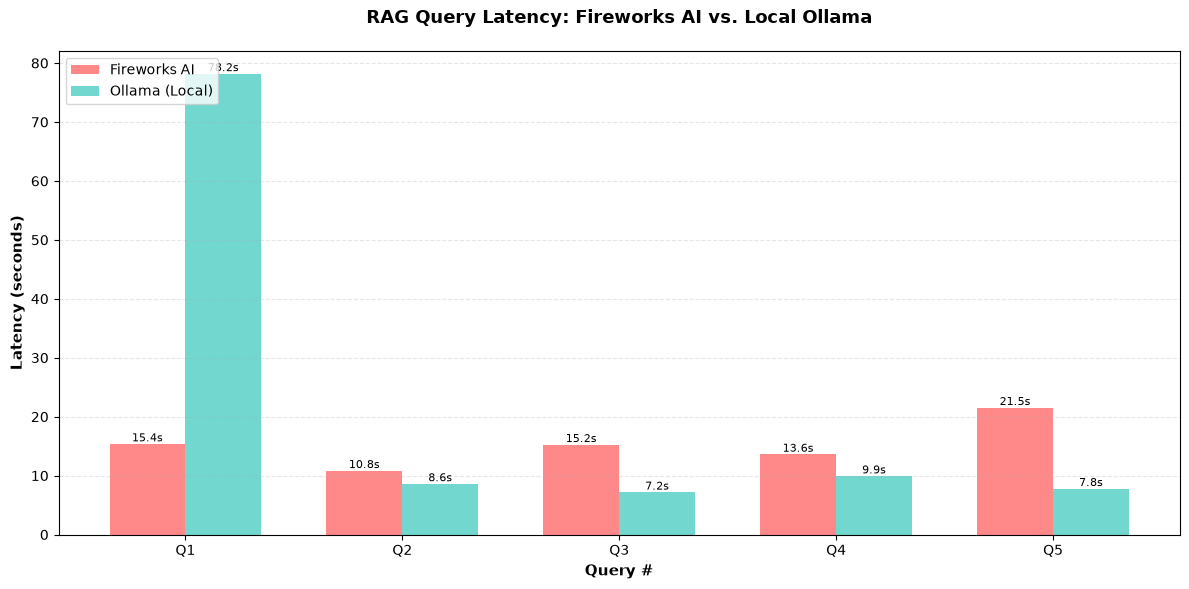

✓ Chart saved as 'latency_comparison.png'


In [11]:
# Create latency comparison chart
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(comparison_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], comparison_df['Fireworks Latency (s)'], width, label='Fireworks AI', alpha=0.8, color='#FF6B6B')
bars2 = ax.bar([i + width/2 for i in x], comparison_df['Ollama Latency (s)'], width, label='Ollama (Local)', alpha=0.8, color='#4ECDC4')

ax.set_xlabel('Query #', fontsize=11, fontweight='bold')
ax.set_ylabel('Latency (seconds)', fontsize=11, fontweight='bold')
ax.set_title('RAG Query Latency: Fireworks AI vs. Local Ollama', fontsize=13, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels([f"Q{i+1}" for i in range(len(comparison_df))])
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}s',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('latency_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Chart saved as 'latency_comparison.png'")

## Step 7: Analysis & Trade-offs

### Key Findings (from this run)

#### Latency
- **Fireworks average latency:** **15.31s** (std **3.93s**)
- **Ollama average latency:** **22.33s** (std **31.23s**)
- The Ollama average is heavily impacted by **Q1 warm-up latency (78.17s)**.
- For **Q2-Q5 only**, Ollama averaged about **8.37s**, which is faster than Fireworks over the same questions (**15.30s**).
- Fireworks was more stable across all 5 queries; Ollama showed higher variance due to first-run load.

#### Answer Quality (observed)
- **Fireworks** gave concise, high-confidence answers on several questions, but returned "I don't know" on some prompts (Q2, Q4).
- **Ollama** produced longer answers for all prompts, including Q2 and Q4 where Fireworks abstained.
- In this run, Fireworks responses were generally more succinct; Ollama responses were generally more verbose and often included contextual lists.

#### Practical Interpretation
- If users care about predictable response times from the first request, Fireworks performed better in this run.
- If local runtime is acceptable and the model is already warm, Ollama can be competitive or faster on subsequent requests.

---

### Trade-offs: Local vs. Managed

| Aspect | Local (Ollama) | Managed (Fireworks) |
|--------|---|---|
| **Cost** | Free after model download | Pay per inference |
| **Latency** | Warm-up can be high; often fast after warm-up | More predictable first-request latency |
| **Throughput** | Limited by local machine | Scales with provider infrastructure |
| **Control** | Full control over model/runtime | Managed service constraints |
| **Privacy** | Data stays local | Data sent to provider |
| **Setup** | Requires local install + model pulls | API key and endpoint only |
| **Reliability** | Depends on local environment | Depends on provider SLA |

---

### Recommendations

**Use Local (Ollama) when:**
- Cost and privacy are top priorities.
- You can tolerate first-query warm-up.
- You run repeated queries in a warmed session.

**Use Managed (Fireworks) when:**
- You need predictable first-request latency.
- You need lower operational burden and stronger production reliability.
- You want easier scaling for user-facing workloads.

**Hybrid approach:**
- Use Ollama for local development and cost-sensitive internal workflows.
- Use Fireworks for production endpoints and latency-sensitive UX.
- Optionally keep Ollama as a fallback path for resilience.